In [4]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

CUDA Available: True
Device Name: NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU


In [1]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from cellpose import io, models, train
from tqdm import tqdm

# Enable Cellpose logging to track training progress
io.logger_setup()

# Configuration
DATA_PATH = r'G:\My Drive\colab\all_data_dict_instance_dilated_CORRECTED.pkl'
SAVE_DIR = r'C:\Users\cja69\phd-github\cobi-phd-code\src\models\cellpose_models'

def normalize_channel(ch):
    ch = np.nan_to_num(ch, nan=0.0)
    c_min, c_max = np.nanmin(ch), np.nanmax(ch)
    if c_max == c_min: return ch
    return ((ch - c_min) / (c_max - c_min + 1e-8)) * 2 - 1

def flatten_channel_preserve_mean(img):
    h, w = img.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    mask = ~np.isnan(img)
    if not np.any(mask): return img
    X_fit, Y_fit, Z_fit = X[mask], Y[mask], img[mask]
    A = np.c_[X_fit.flatten(), Y_fit.flatten(), np.ones(X_fit.size)]
    C, _, _, _ = np.linalg.lstsq(A, Z_fit.flatten(), rcond=None)
    plane = C[0] * X + C[1] * Y + C[2]
    return (img - plane) + np.mean(Z_fit)

print("Loading data...")
with open(DATA_PATH, 'rb') as f:
    all_data_dict = pickle.load(f)

keys = sorted(list(all_data_dict.keys()))
train_keys, val_keys = train_test_split(keys, test_size=0.2, random_state=42)

X_train, Y_train = [], []
X_val, Y_val = [], []

def extract_data(key_list, X_list, Y_list):
    for key in tqdm(key_list):
        data = all_data_dict[key]
        cl_raw = data['m_intensity'].astype(np.float32)[:256, :256]
        cl_centre = data['m_centre'].astype(np.float32)[:256, :256]
        cl_fwhm = data['m_fwhm'].astype(np.float32)[:256, :256]
        
        cl_input = np.stack([
            normalize_channel(cl_raw), 
            normalize_channel(flatten_channel_preserve_mean(cl_centre)), 
            normalize_channel(cl_fwhm)
        ], axis=0)
        
        gt_mask = np.nan_to_num(data['aligned_mask'][:256, :256], nan=0).astype(np.uint16)
        
        X_list.append(cl_input)
        Y_list.append(gt_mask)

print("Preparing training data...")
extract_data(train_keys, X_train, Y_train)
print("Preparing validation data...")
extract_data(val_keys, X_val, Y_val)

# Initialize model from scratch
print("Initializing Cellpose model...")
model = models.CellposeModel(gpu=True, model_type=None)

# Train the model using the updated train_seg API
print("Starting training...")
model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    save_path=SAVE_DIR, 
    n_epochs=200,
    model_name="cellpose_custom_3ch",
    min_train_masks=1
)

print(f"Training complete. Model saved to: {model_path}")

2026-05-28 13:12:24,246 [INFO] WRITING LOG OUTPUT TO C:\Users\cja69\.cellpose\run.log
2026-05-28 13:12:24,247 [INFO] 
cellpose version: 	4.1.1 
platform:       	win32 
python version: 	3.10.19 
torch version:  	2.11.0+cu130
Loading data...
Preparing training data...


100%|██████████| 47/47 [00:00<00:00, 220.60it/s]


Preparing validation data...


100%|██████████| 12/12 [00:00<00:00, 214.79it/s]


Initializing Cellpose model...
2026-05-28 13:12:27,701 [INFO] ** TORCH CUDA version installed and working. **
2026-05-28 13:12:27,701 [INFO] >>>> using GPU (CUDA)
2026-05-28 13:12:28,736 [INFO] >>>> loading model C:\Users\cja69\.cellpose\models\cpsam
Starting training...
2026-05-28 13:12:29,499 [INFO] >>> converting bfloat16 network to float32 for training
2026-05-28 13:12:29,513 [INFO] computing flows for labels


...


100%|██████████| 12/12 [00:00<00:00, 108.43it/s]

2026-05-28 13:12:30,081 [INFO] >>> computing diameters



100%|██████████| 12/12 [00:00<?, ?it/s]

2026-05-28 13:12:30,083 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-05-28 13:12:30,236 [INFO] >>> n_epochs=200, n_train=47, n_test=12
2026-05-28 13:12:30,237 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-05-28 13:12:30,240 [INFO] >>> saving model to C:\Users\cja69\phd-github\cobi-phd-code\src\models\cellpose_models\models\cellpose_custom_3ch
2026-05-28 13:13:26,311 [INFO] 0, train_loss=0.1124, test_loss=0.0981, LR=0.000000, time 56.07s
2026-05-28 13:18:07,404 [INFO] 5, train_loss=0.0923, test_loss=0.0692, LR=0.000006, time 337.16s
2026-05-28 13:22:59,817 [INFO] 10, train_loss=0.0689, test_loss=0.0622, LR=0.000010, time 629.58s
2026-05-28 13:33:11,421 [INFO] 20, train_loss=0.0640, test_loss=0.0599, LR=0.000010, time 1241.18s
2026-05-28 13:42:44,293 [INFO] 30, train_loss=0.0637, test_loss=0.0598, LR=0.000010, time 1814.05s
2026-05-28 13:51:54,012 [INFO] 40, train_loss=0.0622, test_loss=0.0576, LR=0.000010, time 2363.77s
2026-05-28 14:01:03,180 [INFO] 50, train_loss=0.0629, test_loss=0.0588, LR=0.000010, time 2912.94s
2026-05-28 

Loading data and model...
2026-05-29 11:45:21,808 [INFO] ** TORCH CUDA version installed and working. **
2026-05-29 11:45:21,808 [INFO] >>>> using GPU (CUDA)
2026-05-29 11:45:22,831 [INFO] >>>> loading model C:/Users/cja69/phd-github/cobi-phd-code/src/models/cellpose_models/models/cellpose_custom_3ch

Running default evaluation...
Objects detected (Default): 0

Running low-threshold evaluation...
Objects detected (Low Thresholds): 68


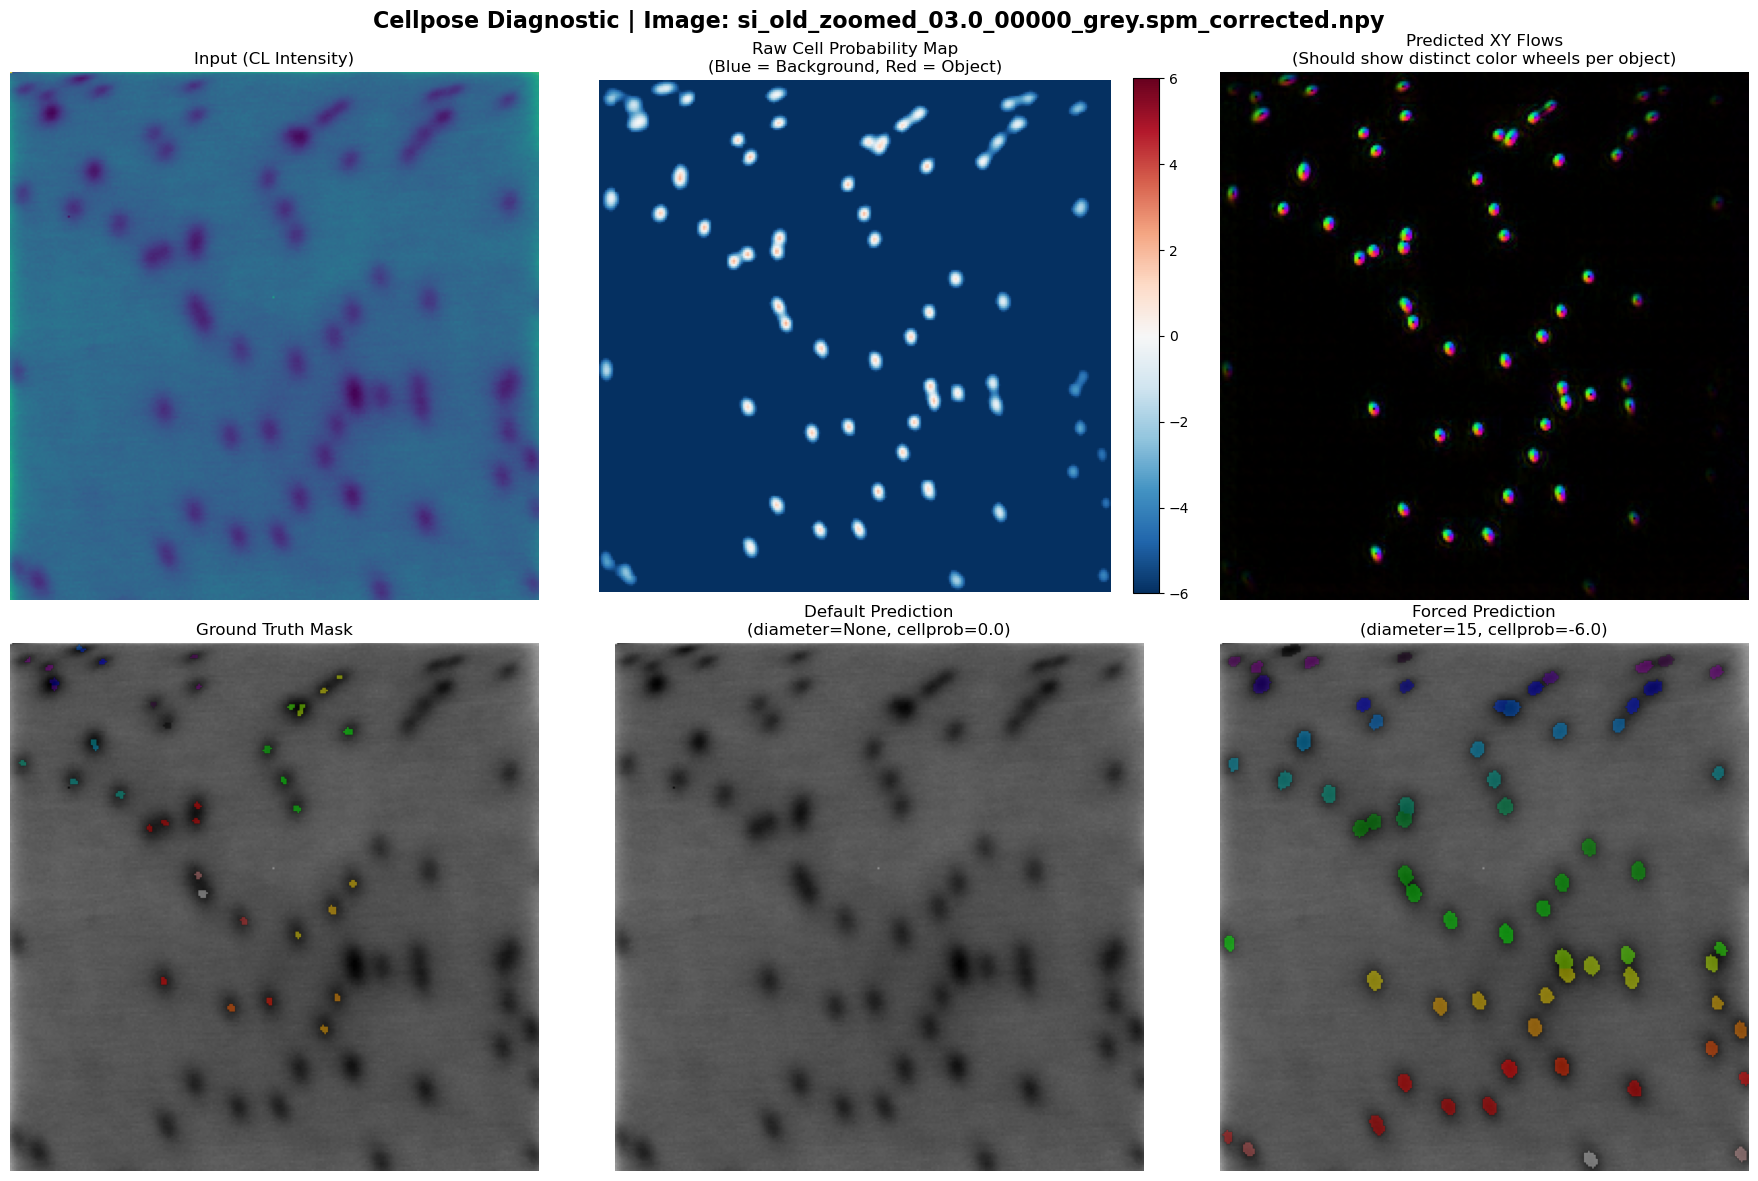

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models
from scipy.ndimage import center_of_mass

# Configuration
DATA_PATH = r'G:\My Drive\colab\all_data_dict_instance_dilated_CORRECTED.pkl'
MODEL_PATH = r'C:/Users/cja69/phd-github/cobi-phd-code/src/models/cellpose_models/models/cellpose_custom_3ch'

def normalize_channel(ch):
    ch = np.nan_to_num(ch, nan=0.0)
    c_min, c_max = np.nanmin(ch), np.nanmax(ch)
    if c_max == c_min: return ch
    return ((ch - c_min) / (c_max - c_min + 1e-8)) * 2 - 1

def flatten_channel_preserve_mean(img):
    h, w = img.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    mask = ~np.isnan(img)
    if not np.any(mask): return img
    X_fit, Y_fit, Z_fit = X[mask], Y[mask], img[mask]
    A = np.c_[X_fit.flatten(), Y_fit.flatten(), np.ones(X_fit.size)]
    C, _, _, _ = np.linalg.lstsq(A, Z_fit.flatten(), rcond=None)
    plane = C[0] * X + C[1] * Y + C[2]
    return (img - plane) + np.mean(Z_fit)

print("Loading data and model...")
with open(DATA_PATH, 'rb') as f:
    all_data_dict = pickle.load(f)

# Select a validation key you know contains dense clusters
test_key = sorted(list(all_data_dict.keys()))[-1] 
data = all_data_dict[test_key]

cl_raw = data['m_intensity'].astype(np.float32)[:256, :256]
cl_centre = data['m_centre'].astype(np.float32)[:256, :256]
cl_fwhm = data['m_fwhm'].astype(np.float32)[:256, :256]
gt_mask = np.nan_to_num(data['aligned_mask'][:256, :256], nan=0)

cl_input = np.stack([
    normalize_channel(cl_raw), 
    normalize_channel(flatten_channel_preserve_mean(cl_centre)), 
    normalize_channel(cl_fwhm)
], axis=0)

model = models.CellposeModel(gpu=True, pretrained_model=MODEL_PATH)

# --- 1. Baseline Evaluation ---
print("\nRunning default evaluation...")
masks_def, flows_def, _ = model.eval(cl_input, diameter=None)#, channels=[0,0])

print(f"Objects detected (Default): {len(np.unique(masks_def)) - 1}")

# --- 2. Forgiving Threshold Evaluation ---
# Lowering cellprob_threshold to -6.0 accepts almost any signal.
# Raising flow_threshold to 3.0 allows highly irregular shapes.
print("\nRunning low-threshold evaluation...")
masks_low, flows_low, _ = model.eval(
    cl_input, 
    diameter=15.0,           # Override auto-diameter with a fixed estimate (adjust this value based on your actual object pixel size)
    cellprob_threshold=-6.0, # Accept low confidence predictions
    flow_threshold=3.0,      # Accept inconsistent flow gradients
    #channels=[0,0]
)
print(f"Objects detected (Low Thresholds): {len(np.unique(masks_low)) - 1}")

# --- 3. Visualization ---
# flows[0] is the RGB representation of the XY flow field.
# flows[2] is the cell probability map (raw logits).
cell_prob_map = flows_def[2]
flow_rgb = flows_def[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f"Cellpose Diagnostic | Image: {test_key}", fontsize=16, weight='bold')

# Row 1: Raw Inputs and Internal Tensors
axes[0, 0].imshow(cl_raw, cmap='viridis')
axes[0, 0].set_title("Input (CL Intensity)")

# The raw sigmoid output. Values > 0 are considered objects by default.
im = axes[0, 1].imshow(cell_prob_map, cmap='RdBu_r', vmin=-6, vmax=6)
axes[0, 1].set_title("Raw Cell Probability Map\n(Blue = Background, Red = Object)")
plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[0, 2].imshow(flow_rgb)
axes[0, 2].set_title("Predicted XY Flows\n(Should show distinct color wheels per object)")

# Row 2: Outputs
display_gt = gt_mask.astype(float)
display_gt[display_gt == 0] = np.nan
axes[1, 0].imshow(cl_raw, cmap='gray')
axes[1, 0].imshow(display_gt, cmap='nipy_spectral', alpha=0.5)
axes[1, 0].set_title("Ground Truth Mask")

display_def = masks_def.astype(float)
display_def[display_def == 0] = np.nan
axes[1, 1].imshow(cl_raw, cmap='gray')
axes[1, 1].imshow(display_def, cmap='nipy_spectral', alpha=0.5)
axes[1, 1].set_title("Default Prediction\n(diameter=None, cellprob=0.0)")

display_low = masks_low.astype(float)
display_low[display_low == 0] = np.nan
axes[1, 2].imshow(cl_raw, cmap='gray')
axes[1, 2].imshow(display_low, cmap='nipy_spectral', alpha=0.5)
axes[1, 2].set_title("Forced Prediction\n(diameter=15, cellprob=-6.0)")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()